In [1]:
import pandas as pd
import numpy as np

# Load data
train_df = pd.read_csv('archive/train.csv')
test_df = pd.read_csv('archive/test.csv')


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 3073 entries, pixel_0 to label
dtypes: int64(3073)
memory usage: 1.1 GB


In [3]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 3072 entries, pixel_0 to pixel_3071
dtypes: int64(3072)
memory usage: 234.4 MB


In [5]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Extract labels and pixels from train_df
X = train_df.drop('label', axis=1).values  # shape: (50000, 3072)
y = train_df['label'].values  # shape: (50000,)

# Reshape pixels into images (32, 32, 3)
X = X.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # Convert from (N,3,32,32) to (N,32,32,3)

# Normalize images
X = X / 255.0

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

# Check a sample image shape
print(X_train[0].shape)


2025-08-21 10:37:25.845251: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-21 10:37:25.984179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755752846.033598    9389 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755752846.047659    9389 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755752846.162915    9389 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Train shape: (45000, 32, 32, 3), Validation shape: (5000, 32, 32, 3)
(32, 32, 3)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_val, y_val_cat))


/home/ai-a2/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-21 10:37:40.230465: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3820 - loss: 1.6932 - val_accuracy: 0.5776 - val_loss: 1.2066
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6078 - loss: 1.1188 - val_accuracy: 0.6274 - val_loss: 1.0499
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6690 - loss: 0.9487 - val_accuracy: 0.6650 - val_loss: 0.9795
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7055 - loss: 0.8444 - val_accuracy: 0.6628 - val_loss: 0.9576
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7353 - loss: 0.7571 - val_accuracy: 0.7028 - val_loss: 0.8694
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7684 - loss: 0.6656 - val_accuracy: 0.6936 - val_loss: 0.9064
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7878 - loss: 0.6099 - val_accuracy: 0.7096 - val_loss: 0.8812
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8114 - loss: 0.5367 - 

In [7]:
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Parameters
input_shape = (32, 32, 3)
num_classes = 10  # CIFAR-10 classes

# MobileNetV2 base
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze base layers initially
mobilenet_base.trainable = False

# Add custom top layers
x = mobilenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=mobilenet_base.input, outputs=predictions)

mobilenet_model.compile(optimizer=Adam(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Train MobileNetV2 model
history_mobilenet = mobilenet_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=64
)


/tmp/ipykernel_9389/2820693154.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2337 - loss: 2.1121 - val_accuracy: 0.3142 - val_loss: 1.8901
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3059 - loss: 1.9223 - val_accuracy: 0.3214 - val_loss: 1.8561
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3170 - loss: 1.8850 - val_accuracy: 0.3290 - val_loss: 1.8365
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3240 - loss: 1.8590 - val_accuracy: 0.3330 - val_loss: 1.8247
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3305 - loss: 1.8506 - val_accuracy: 0.3328 - val_loss: 1.8140
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3347 - loss: 1.8323 - val_accuracy: 0.3350 - val_loss: 1.8109
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3356 - loss: 1.8349 - val_accuracy: 0.3382 - val_loss: 1.8037
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 1

In [8]:
# ResNet50 base
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=predictions)

resnet_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_resnet = resnet_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=64
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.1058 - loss: 2.3681 - val_accuracy: 0.1632 - val_loss: 2.2447
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.1243 - loss: 2.2543 - val_accuracy: 0.1648 - val_loss: 2.1958
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.1266 - loss: 2.2426 - val_accuracy: 0.1632 - val_loss: 2.1903
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.1326 - loss: 2.2366 - val_accuracy: 0.1766 - val_loss: 2.1721
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.1319 - loss: 2.2332 - val_accuracy: 0.1792 - val_loss: 2.1694
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.1406 - loss: 2.2242 - val_accuracy: 0.1646 - val_loss: 2.1644
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.1433 - loss: 2.2220 - val_accuracy: 0.1850 - val_loss: 2.1752
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━

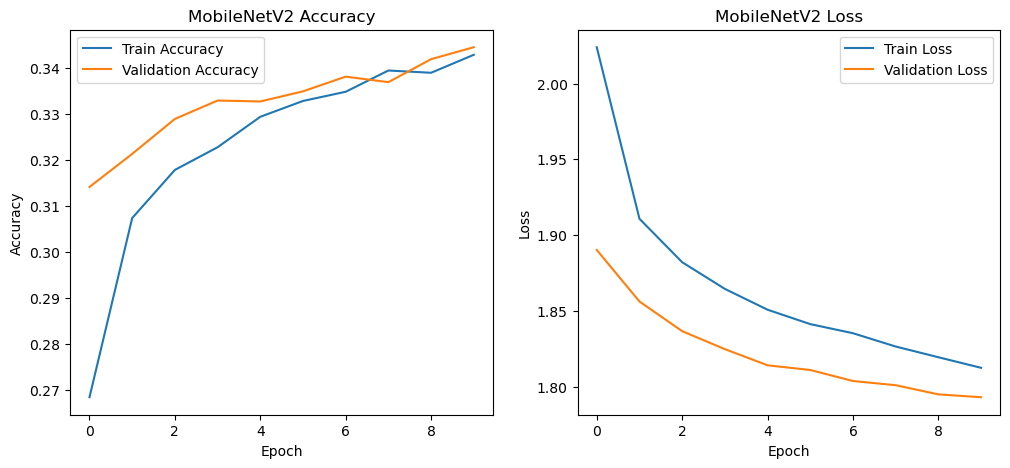

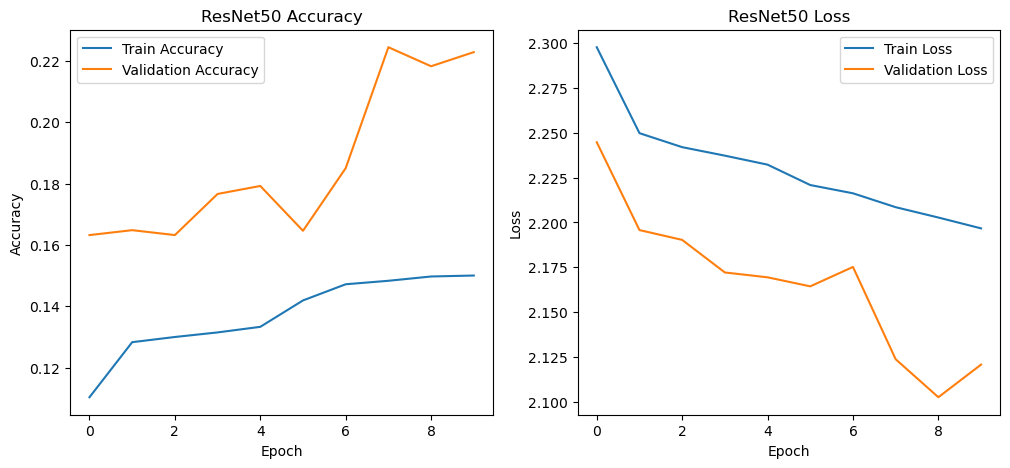

In [9]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Plot for MobileNetV2
plot_history(history_mobilenet, 'MobileNetV2')

# Plot for ResNet50
plot_history(history_resnet, 'ResNet50')
